Creating 6 seperate seasonal pm10 maps...
State PM10 range for consistent coloring: 0.06 - 151.93 µg/m³

Creating map for 2024Spring with 17 sensors...


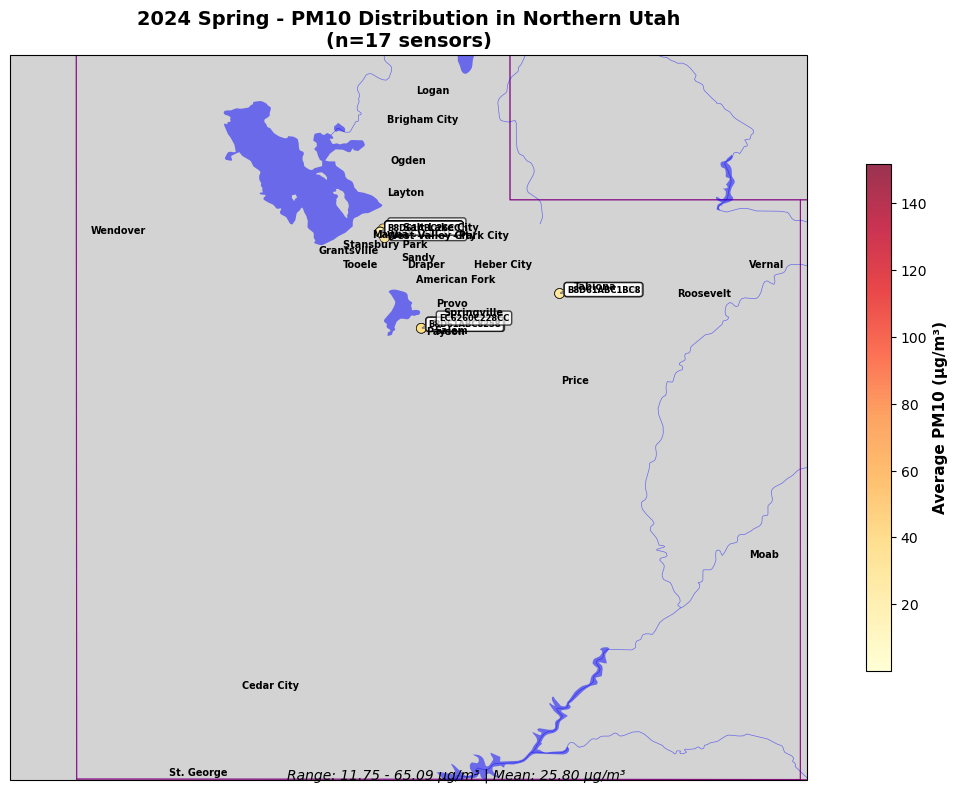


Creating map for 2024Summer with 31 sensors...


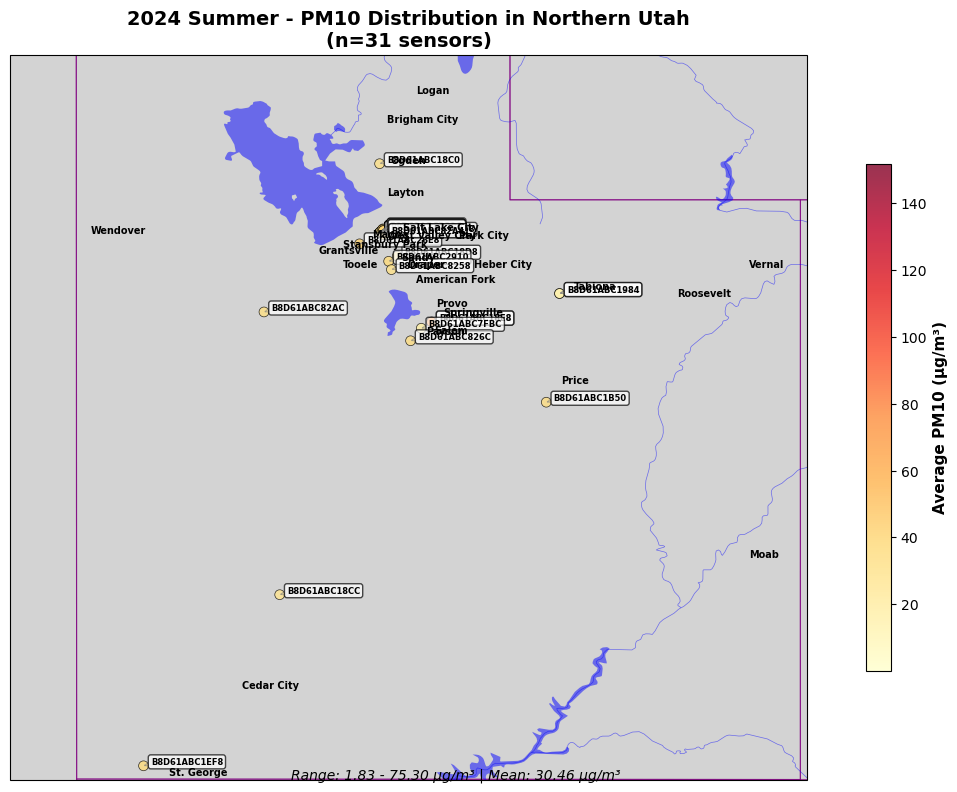


Creating map for 2024Winter with 28 sensors...


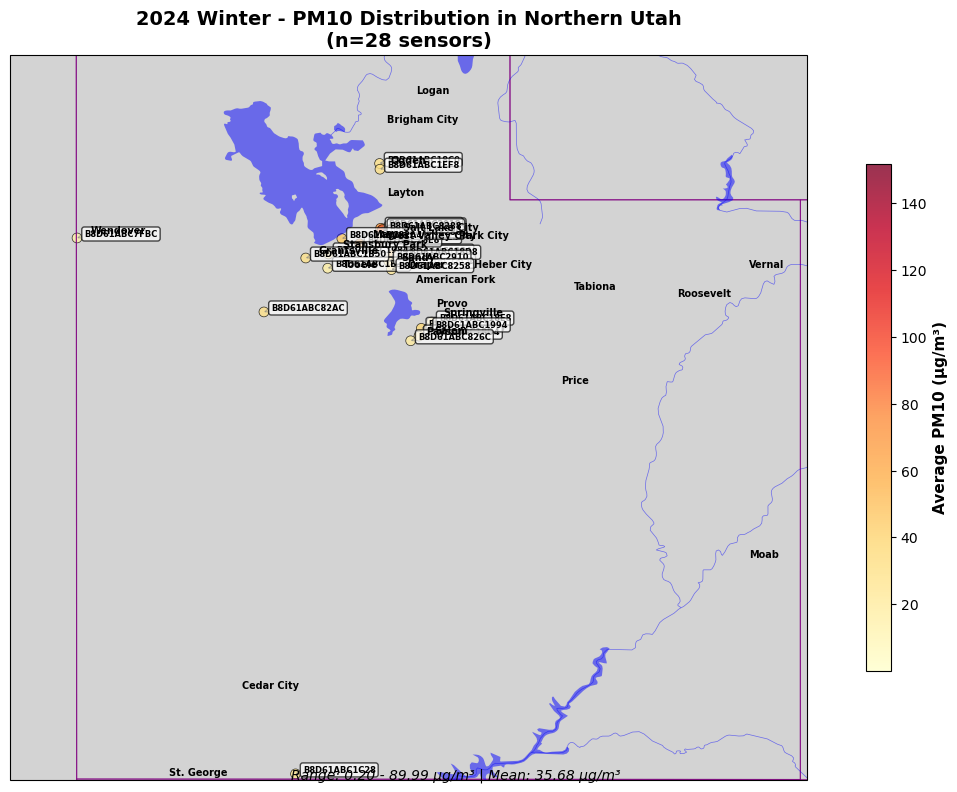


Creating map for 2025Spring with 24 sensors...


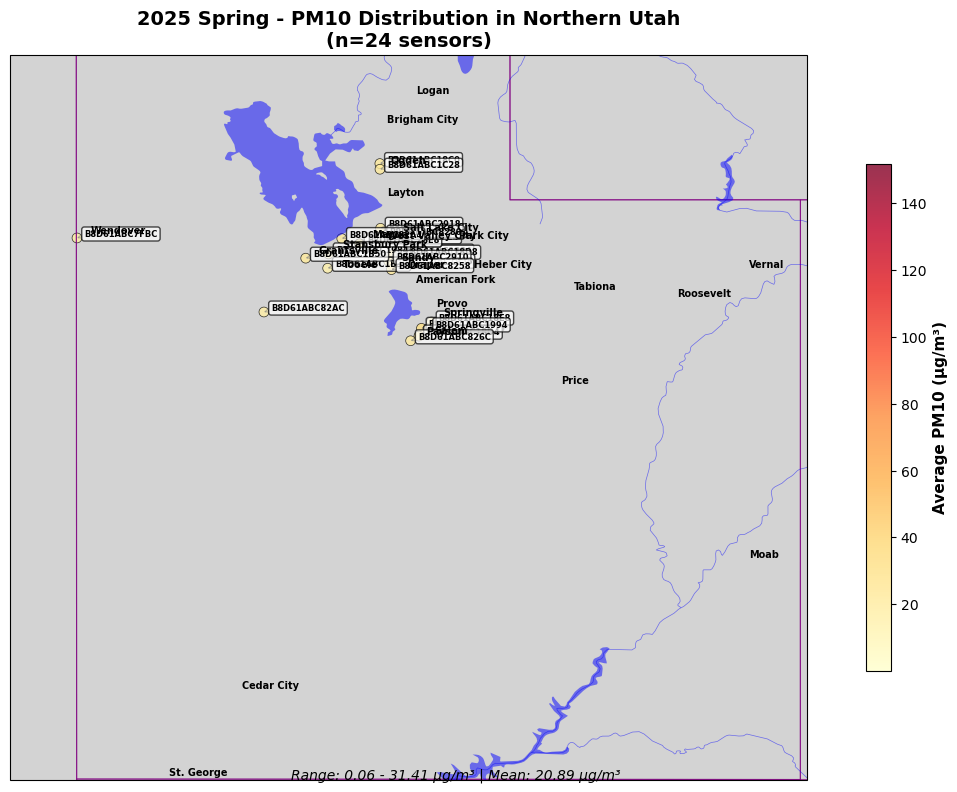


Creating map for 2025Summer with 30 sensors...


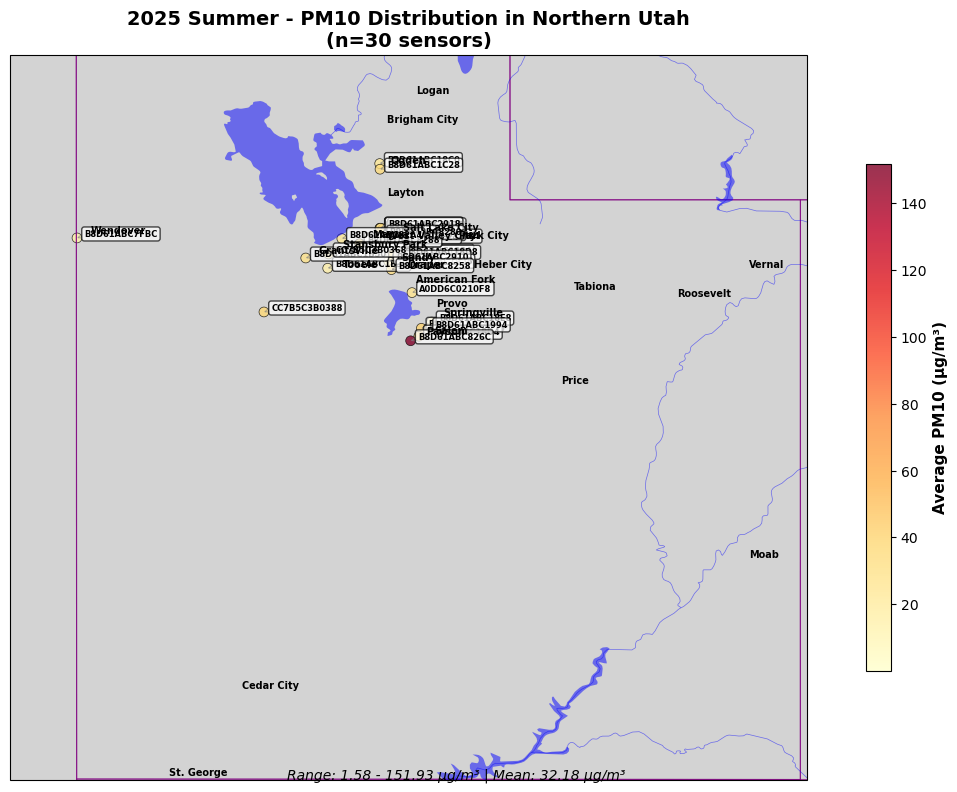


Creating map for 2025Winter with 33 sensors...


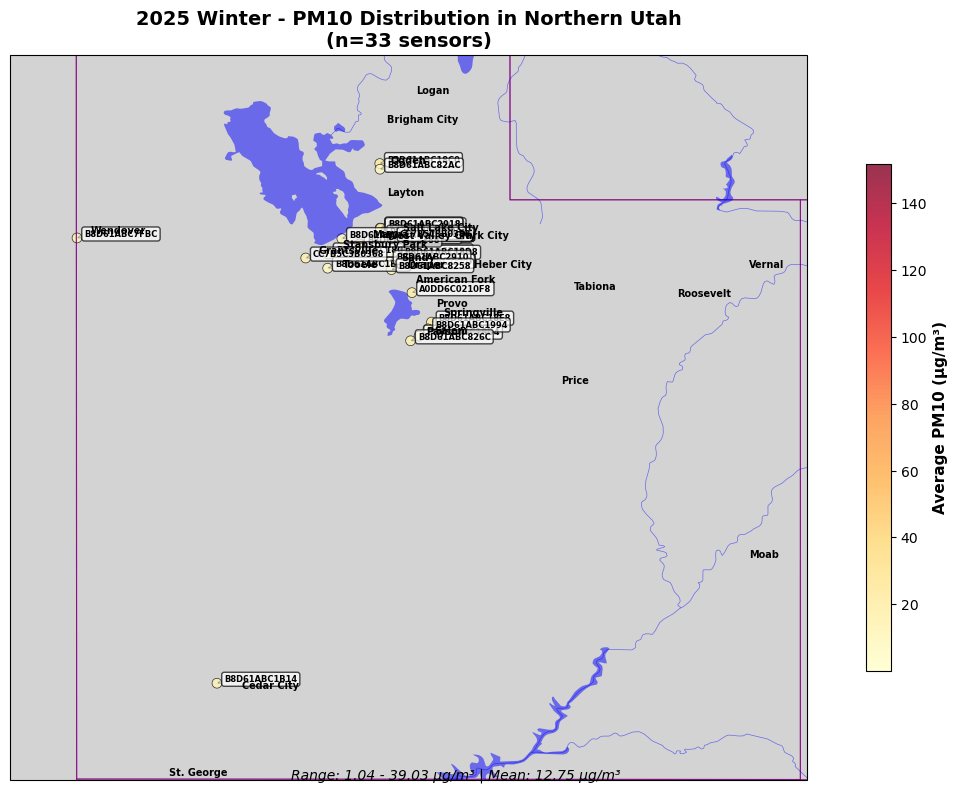

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import numpy as np
from pathlib import Path

seasonal_data = pd.read_csv('Clean_PlotData.csv')
seasons = ['2024Spring', '2024Summer', '2024Winter', '2025Spring', '2025Summer', '2025Winter']
print("="*50)
print("Creating 6 seperate seasonal pm10 maps...")
print("="*50)


#cities
cities = {'Salt Lake City': (-111.8910, 40.7608), 
        'Provo': (-111.6581, 40.2338), 
        'Ogden': (-111.9740, 41.2230),
        'Logan': (-111.8, 41.7),
        'West Valley City': (-112, 40.70),
        'Sandy': (-111.9, 40.55),
        'Layton': (-112, 41),
        'American Fork': (-111.8, 40.4),
        'Park City': (-111.5, 40.7),
        'Price': (-110.8, 39.7),
        'St. George': (-113.5, 37.0),
        'Cedar City': (-113.0, 37.6),
        'Moab': (-109.5, 38.5),
        'Tooele': (-112.3, 40.5),
        'Brigham City': (-112.0, 41.5),
        'Magna': (-112.1, 40.71),
        'Tabiona': (-110.71, 40.35),
        'Springville': (-111.61, 40.17),
        'Salem': (-111.67, 40.05),
        'Wendover': (-114.04, 40.74),
        'Draper': (-111.86, 40.5),
        'Stansbury Park': (-112.3, 40.64),
        'Payson': (-111.73, 40.04),
        'Grantsville': (-112.47, 40.6)
}

#calc for state min/max
state_min = seasonal_data['avg_pm10'].min()
state_max = seasonal_data['avg_pm10'].max()
print(f"State PM10 range for consistent coloring: {state_min:.2f} - {state_max:.2f} µg/m³")

for season in seasons:
    season_df = seasonal_data[seasonal_data['season'] == season]

    if season_df.empty:
        print(f"No data available for {season}, skipping...")
        continue
    print(f"\nCreating map for {season} with {len(season_df)} sensors...")

    #creates the figure and axis
    fig, ax = plt.subplots(figsize=(12, 8), subplot_kw={'projection': ccrs.PlateCarree()})
    ax.set_extent([-114.5, -109.0, 37.0, 42.0])

    ax.add_feature(cfeature.STATES, linewidth=0.8, edgecolor='purple', alpha=0.7)
    ax.add_feature(cfeature.LAND, facecolor='lightgray')
    ax.add_feature(cfeature.BORDERS, linewidth=0.5)
    ax.add_feature(cfeature.LAKES, facecolor='blue', alpha=0.5)
    ax.add_feature(cfeature.RIVERS, linewidth=0.5, edgecolor='blue', alpha=0.5)

    scatter = ax.scatter(season_df['longitude'], season_df['latitude'],
                       c=season_df['avg_pm10'],
                       cmap='YlOrRd',  # Yellow to Red colormap
                       s=50,
                       alpha=0.8,
                       transform=ccrs.PlateCarree(),
                       vmin=state_min,
                       vmax=state_max,
                       edgecolors='black',
                       linewidth=0.5)
    
    for idx, row in season_df.iterrows():
        sensor_label = row['sensor_id']
        ax.annotate(sensor_label, 
                   xy=(row['longitude'], row['latitude']),
                   xytext=(row['longitude'] + 0.05, row['latitude'] + 0.01),
                   transform=ccrs.PlateCarree(),
                   fontsize=6,
                   color='black',
                   weight='bold',
                   zorder=5,
                   bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.7),
                   arrowprops=dict(arrowstyle='->', 
                                 connectionstyle='arc3,rad=0.1',
                                 color='gray',
                                 alpha=0.5))
    
    for city, (lon, lat) in cities.items():
        ax.text(lon + 0.1, lat + 0.03, city,
               transform=ccrs.PlateCarree(),
               fontsize=7,
               fontweight='bold',
               color='black',
               zorder=6)
        
    cbar = plt.colorbar(scatter, ax=ax, orientation='vertical', pad=0.05, shrink=0.7)
    cbar.set_label('Average PM10 (µg/m³)', fontsize=11, fontweight='bold')

    season_display = season.replace('2024', '2024 ').replace('2025', '2025 ')

    plt.title(f'{season_display} - PM10 Distribution in Northern Utah\n(n={len(season_df)} sensors)', 
              fontsize=14, fontweight='bold')
    
    season_min = season_df['avg_pm10'].min()
    season_max = season_df['avg_pm10'].max()
    season_mean = season_df['avg_pm10'].mean()
    plt.figtext(0.5, 0.02, 
                f'Range: {season_min:.2f} - {season_max:.2f} µg/m³ | Mean: {season_mean:.2f} µg/m³', 
                ha='center', fontsize=10, style='italic')
    
    plt.tight_layout()
    plt.show()
